## EfficientNet - 512*512 center crop data

- Data Size: 약 69898장(6.6 GB)
- Label 수: 13개
- Image size: 512*512, RGB

In [84]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim import Adam
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision
from tensorboardX import SummaryWriter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

#### 데이터 전처리 정의

In [41]:
transforms_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### 데이터 불러오기

In [66]:
full_datasets = datasets.ImageFolder(root='../datasets/data')
class_names = full_datasets.classes
class_names

['금속캔알루미늄캔',
 '금속캔철캔',
 '비닐',
 '스티로폼',
 '유리병갈색',
 '유리병녹색',
 '유리병투명',
 '종이',
 '페트병무색단일',
 '페트병유색단일',
 '플라스틱PE',
 '플라스틱PP',
 '플라스틱PS']

### 데이터 불균형 확인 / 클래스 별 가중치 생성

In [88]:
label_counts = Counter(full_datasets.targets)

print("Class distribution in full_datasets:")
print(label_counts)

# 클래스 인덱스 순서대로 정렬하여 리스트 생성
sorted_counts = [label_counts[i] for i in sorted(label_counts.keys())]

# 각 클래스 데이터 수의 역수 계산
class_weights = 1.0 / torch.tensor(sorted_counts, dtype=torch.float)

# 전체 합이 1이 되도록 정규화
class_weights /= class_weights.sum()

print("계산된 클래스 가중치:", class_weights)

Class distribution in full_datasets:
Counter({11: 9118, 12: 9112, 8: 9104, 9: 7707, 1: 7016, 10: 5968, 0: 4966, 7: 4963, 3: 3501, 6: 2141, 2: 2103, 4: 2101, 5: 2098})
계산된 클래스 가중치: tensor([0.0601, 0.0425, 0.1418, 0.0852, 0.1420, 0.1422, 0.1393, 0.0601, 0.0328,
        0.0387, 0.0500, 0.0327, 0.0327])


#### 학습용과 시험용으로 데이터 쪼개기

In [90]:
# train_size = int(total_size * 0.8)
# test_size = total_size - train_size
# train_dataset, test_dataset = torch.utils.data.random_split(
#     full_datasets,
#     [train_size, test_size],
#     generator=torch.Generator().manual_seed(42)
# )

# 데이터 크기와 target 저장 
total_size = len(full_datasets)
targets = full_datasets.targets

train_indices, test_indices = train_test_split(
    np.arange(total_size),
    test_size=0.2,
    stratify=targets,
    random_state=42   
)

train_dataset = torch.utils.data.Subset(full_datasets, train_indices)
test_dataset = torch.utils.data.Subset(full_datasets, test_indices)

print("\n데이터셋 분할 완료.")
print(f"총 데이터 수: {total_size}")
print(f"학습용 데이터 수: {len(train_dataset)}")
print(f"검증용 데이터 수: {len(test_dataset)}")




데이터셋 분할 완료.
총 데이터 수: 69898
학습용 데이터 수: 55918
검증용 데이터 수: 13980


- 전처리 적용

In [91]:
train_dataset.dataset.trnsform = transforms_train
test_dataset.dataset.transform = transforms_test

In [92]:
train_dataset

In [93]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
11


- 미니배치 사이즈로 쪼개기

In [94]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [95]:
next(iter(train_loader))[0].shape # train_loader 첫번째 배치

torch.Size([32, 3, 224, 224])

#### 이미지 확인해 보기

In [96]:
## 이미지 시각화를 함수로 정의

def imshow(img, title):
    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()
    

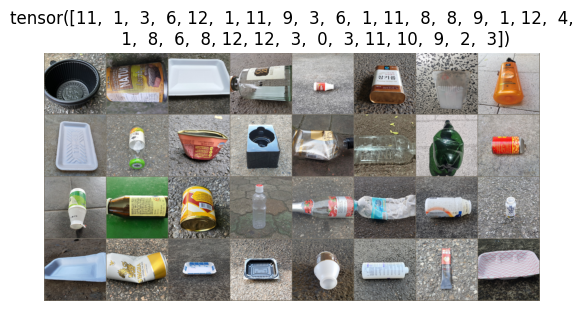

In [97]:
images, labels = next(iter(train_loader))
images_data = torchvision.utils.make_grid(images)

imshow(images_data, labels)

#### 모델 생성

In [58]:
# weights = models.EfficientNet_B0_Weights.DEFAULT
# model = models.efficientnet_b0(weights=weights)

# model

In [98]:
def build_efficientnet_model(num_classes=13):
    # EfficientNet_B0_Weights.DEFAULT는 ImageNet으로 사전 학습된 기본 가중치를 의미
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    # 모든 레이어의 가중치를 재학습 가능하도록 설정
    # torchvision의 모델은 기본적으로 requires_grad=True 이므로 이코드는 생략 가능하지만 명시적으로 표시한거
    for param in model.parameters():
        param.requires_grad = True
    
    # 마지막 분류 레이어(classifier) 수정
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features=num_features, out_features=num_classes)

    return model


In [99]:
my_model = build_efficientnet_model(13)

print(my_model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### 모델 학습(기본)

In [103]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# writer = SummaryWriter()

# lr = 1e-3
# optimizer = torch.optim.Adam(my_model.parameters(), lr=lr)
# criterion = nn.CrossEntropyLoss(weight=class_weights)
# epochs = 2
# step = 0

# my_model.to(device)

# for epoch in range(epochs):
#     for images, labels in tqdm(train_loader):
#         images = images.to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()

#         preds = my_model(images)
#         loss = criterion(preds, labels)

#         loss.backward()
#         optimizer.step()

#         writer.add_scalar("Loss/train", loss.item(), step)
#         step += 1
    
#     print(f"{epoch}: epoch loss: {loss.item()}")




### 모델 학습(클래스 별 가중치 적용, Early Stopping 적용)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

my_model.to(device)

writer = SummaryWriter()

lr = 1e-3
optimizer = torch.optim.Adam(my_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
epochs = 10
step = 0

# 조기 종료를 위한 변수 설정
best_loss = float('inf') # 가장 낮은 검증 손실을 저장할 변수
patience = 5 # 손실 개선이 없을 때 기다릴 에포크 횟수
counter = 0 # patience 카운터

# 결과 모델을 저장할 경로
model_save_path = "model/best_efficientnet_model.pth"

for epoch in range(epochs):
    # ------------------
    # 1. 모델 학습 (Training)
    # ------------------
    my_model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} (Training)"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        preds = my_model(images)
        loss = criterion(preds, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        writer.add_scalar("Loss/train", loss.item(), step)
        step += 1

    avg_train_loss = train_loss / len(train_loader.dataset)

    # ------------------
    # 2. 모델 평가 (Validation)
    # ------------------
    my_model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} (Validation)"):
            images, labels = images.to(device), labels.to(device)

            preds = my_model(images)
            loss = criterion(preds, labels)
            valid_loss += loss.item() * images.size(0)

    avg_valid_loss = valid_loss / len(test_loader.dataset)
    writer.add_scalar("Loss/validation", avg_valid_loss, epoch)
        
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}")
    
    # ------------------
    # 3. 조기 종료 로직
    # ------------------

    if avg_valid_loss < best_loss:
        print(f"Validation loss decreased from {best_loss:.4f} to {avg_valid_loss:.4f}. Saving model...")
        best_loss = avg_valid_loss
        counter = 0
        torch.save(my_model.state_dict(), f"model/best_efficient_model_epoch{epoch}_weights.pth")
    else:
        counter += 1
        print("Validation loss가 낮아지지 않음. Early stopping counter: {counter}/{patience}")
    if counter >= patience:
        print(f"Early stopping 발생 {patience}번 동안 loss 줄어들지 않음")
        break
print("학습 완료")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = my_model(images)
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())




In [72]:
# 스코어 계산
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
accuracy = (np.array(y_true) == np.array(y_pred)).mean()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy : 0.8559
Precision: 0.8596
Recall   : 0.8559
F1-score : 0.8563
              precision    recall  f1-score   support

    금속캔알루미늄캔       0.89      0.89      0.89       985
       금속캔철캔       0.92      0.86      0.89      1447
          비닐       0.89      0.81      0.85       412
        스티로폼       0.95      0.95      0.95       695
       유리병갈색       0.87      0.87      0.87       423
       유리병녹색       0.90      0.86      0.88       411
       유리병투명       0.90      0.77      0.83       442
          종이       0.90      0.91      0.90      1026
     페트병무색단일       0.88      0.94      0.91      1826
     페트병유색단일       0.83      0.80      0.82      1537
      플라스틱PE       0.70      0.87      0.77      1182
      플라스틱PP       0.85      0.81      0.83      1826
      플라스틱PS       0.82      0.80      0.81      1768

    accuracy                           0.86     13980
   macro avg       0.87      0.86      0.86     13980
weighted avg       0.86      0.86      0.86     13980

